# Joint-angle fPCA — 60 m sprint

## Why this notebook exists

The old fPCA ran on marker **positions**. A position carries units of length, so
the first component measured *how big the athlete was*, not how they moved: PC1
took **96.5 %** of the variance while correlating only **r = +0.24** with peak
velocity. A component that explains almost everything and predicts almost nothing
is an artefact. Height-scaling everyone to a common stature does not fix it,
because equal stature still leaves limb proportions mismatched.

This notebook feeds PCA **joint angles**. An angle is a ratio of two lengths, so
it has no units and cannot encode stature.

## How the code is arranged

| file | what it holds |
|---|---|
| `sprint_pipeline.py` | sections 1–6, 9, 10 — loading, cleaning, segmentation, angles, fPCA, models. Data only. |
| `sprint_pipeline.ipynb` | the same sections walked one stage at a time, `.head()` and `.shape` on every table |
| `sprint_outputs.py` | sections 7–8 — every figure and every athlete's MP4 |

This notebook is the *argument*: what each step is for, and what came out. Read
`sprint_pipeline.py` when you want to know how something works, `sprint_pipeline.ipynb`
when you want to check it stage by stage, and this when you want to know why.

Height is **measured**, from the anthropometrics spreadsheet. Nothing in the
pipeline derives it from marker positions.

## Two branches, kept apart on purpose

| branch | input | height-scaled? | answers |
|---|---|---|---|
| events | `raw64` | yes | contact time, stride length, peak velocity |
| angles | `raw64` | **never** | movement patterns — this notebook |

Angles are already size-free, so scaling them would add nothing — and it would
quietly rescale velocity too, which section G covers.

In [1]:
from project_paths import PATHS

import numpy as np
import pandas as pd

import sprint_pipeline as SP
from sprint_pipeline import *      # C3D_DIR, clean_for_angles, ANGLE_NAMES, ...
import sprint_outputs as OUT       # sections 7-8: every figure, every MP4

print(f"{len(sorted(C3D_DIR.glob('*.c3d')))} trials found, excluding {EXCLUDED_PIDS}")
print(f"{len(PARTICIPANT_ANTHRO)} participants in the anthropometrics sheet")

31 trials found, excluding ['SB17']
31 participants in the anthropometrics sheet


## A · Alignment

Some exported videos came out rotated a few degrees off square. Two causes: the
forward axis came from an SVD of the whole marker cloud, which lateral drift tugs
on, and the lead-in was cut with a hardcoded step *backwards* that dragged
block-exit frames — where the athlete is still turning into their lane — into the
alignment window.

The fix takes forward from the athlete's own displacement: **pelvis at the start
→ pelvis at the end**, measured *after* the 62 m trim and skipping the first
stride. That brings the residual travel angle to exactly 0°.

**Gravity is left alone.** The Xsens IMU supplies a gravity-aligned vertical, so
Z is correct as recorded; only the horizontal plane is rotated.

**Where the sprint starts.** In the set position all four contact points are on
the track, and the hands leave once and never return — so the last frame the
hands are still down is the start. A velocity threshold gives the coarse anchor
and the hands refine it, searched only within ±1.5 s of that anchor because some
recordings have 10–20 s of lead-in while the athlete walks in and settles.

In [2]:
tilt = alignment_report()
print(f"tilt correction: median {tilt.tilt_deg.median():.2f} deg, "
      f"worst {tilt.tilt_deg.max():.2f} deg")
tilt.head(6)

tilt correction: median 0.09 deg, worst 0.76 deg


,pid,tilt_deg,peak_v
0,SB153,0.76,7.59
1,SB15,0.65,8.43
2,SB23,0.50,8.22
3,SB151,0.36,8.14
4,SB110,0.25,7.78
5,SB74,0.20,8.94


## B · Segmentation

Before any fPCA the strides have to actually *be* strides. The older detector
required foot contacts to be ≥ 30 frames apart, but a top-speed stride at 60 Hz
lasts 27–30 frames — so it **rejected genuine contacts** and returned windows
spanning two or three strides glued together. That broke 26 of 30 participants,
and the breakage was speed-dependent: fast athletes have short stride periods and
got corrupted, slow ones did not.

The corrected detector separates contacts by 18 frames and then **validates every
window**, discarding anything outside 22–40 frames rather than silently averaging
it.

Acceleration needs a different unit. A step there is contact to contact of
**alternate** feet, because out of the blocks the two legs are doing different
jobs and a same-foot stride would hide exactly that asymmetry.

In [3]:
t = clean_for_angles("SB25")
strides, rejected = find_top_speed_strides(t["mk"], t["peak_frame"])
steps, _          = find_first_steps(t["mk"], n_steps=3)

print(f"SB25 top-speed strides : {[b - a for a, b in strides]} frames, {rejected} rejected")
print(f"      (the old detector returned [54, 30, 32] for this trial)")
print(f"SB25 first three steps : {[b - a for a, b in steps]} frames")

SB25 top-speed strides : [27, 27, 27, 30, 32] frames, 0 rejected
      (the old detector returned [54, 30, 32] for this trial)
SB25 first three steps : [16, 13, 20] frames


## C · Joint angles

`mk` holds segment **centroids**, not joint centres — "Right Upper Leg" is the
midpoint of the trochanter and the knee, which is neither joint. So angles come
from `raw64`, which carries the anatomical landmarks directly.

**Thirteen** angles: legs, arms and trunk. The arms are in the *analysis*, not
just the drawing — the prior work this project cites reports contralateral
arm–leg timing as what separates faster from slower sprinters.

Each angle is the turn from the **parent segment to the child**. Measuring each
segment against vertical and subtracting looks equivalent but is not: an arm
swinging above the shoulder crosses the ±180° wrap point, and the subtraction then
reports a near-full rotation — a 219° shoulder range, which nobody has. Two bones
joined at a joint can only fold so far, so segment-to-segment cannot wrap.

In [4]:
angles, names = compute_joint_angles(t["raw64"])
pd.DataFrame({"angle": names,
              "min":  angles.min(0).round(1),
              "max":  angles.max(0).round(1),
              "ROM":  np.ptp(angles, axis=0).round(1)})

,angle,min,max,ROM
0,hip_R,-42.1,83.2,125.3
1,hip_L,-44.1,118.4,162.5
2,knee_R,-9.3,137.6,146.9
3,knee_L,-5.3,140.8,146.1
4,ankle_R,-56.5,32.4,88.9
5,ankle_L,-46.2,41.7,87.9
6,shoulder_R,-83.7,79.0,162.7
7,shoulder_L,-81.9,111.0,192.9
8,elbow_R,-19.2,141.6,160.8
9,elbow_L,-0.9,137.6,138.5


## D · Build the cohort

0 % of a cycle is foot contact, 100 % is the next contact of the same foot, 101
samples. Phase is the only fair axis: stride frequency drifts while accelerating,
so comparing at equal frame number or equal metres would compare different parts
of the movement.

`stride_cycle_angles` also returns a **phase spread** — how far the moment of peak
knee flexion moves between cycles. If they are the same movement it lands in
nearly the same place every time and averaging is safe; if it scatters, the
average smears the peaks away. That is the guard against the failure above
recurring silently.

Both phases are built in one pass. Marker positions are kept alongside the angles
for the anatomy figures, scaled to a common stature **for drawing only** so that
averaging different-sized athletes does not blur the mean.

In [5]:
cohort, cohort_raw, accel, accel_raw = {}, {}, {}, {}
peak_vel, body_height, spread_top, spread_acc = {}, {}, [], []

for fpath in sorted(C3D_DIR.glob("*.c3d")):
    pid = fpath.stem.split("-")[0].strip()
    if pid in EXCLUDED_PIDS:
        continue
    try:
        tr = clean_for_angles(fpath)
        hs = height_scale_for(pid, 1.75)            # drawing only

        cy, _n, sp = stride_cycle_angles(tr["raw64"], tr["mk"], tr["peak_frame"])
        if cy is None:
            continue
        cohort[pid]     = cy
        cohort_raw[pid] = stride_cycle_raw64(tr["raw64"], tr["mk"], tr["peak_frame"],
                                             hscale=hs)
        spread_top.append(sp)

        steps, _ = find_first_steps(tr["mk"], n_steps=3)
        if len(steps) == 3:
            ac, _n, sa = stride_cycle_angles(tr["raw64"], tr["mk"], tr["peak_frame"],
                                             windows=steps)
            accel[pid]     = ac
            accel_raw[pid] = stride_cycle_raw64(tr["raw64"], tr["mk"], tr["peak_frame"],
                                                hscale=hs, windows=steps)
            spread_acc.append(sa)

        peak_vel[pid]    = tr["peak_vel_ms"]        # UNSCALED - see section G
        body_height[pid] = PARTICIPANT_ANTHRO[pid]["body_height"]
    except Exception as e:
        print(f"  skipped {pid}: {e}")

print(f"top speed    : {len(cohort)} participants, phase spread median {np.median(spread_top):.0f} %")
print(f"acceleration : {len(accel)} participants, phase spread median {np.median(spread_acc):.0f} %")

top speed    : 30 participants, phase spread median 3 %
acceleration : 30 participants, phase spread median 90 %


The two phase spreads say something important. At top speed every stride repeats
the same movement, so the spread is small and averaging is safe. The first three
steps are a **progression** — step 1 is not step 3 — so the spread is large by
nature. That average summarises early acceleration; it is not a canonical cycle
the way the top-speed one is.

## E · Smooth with a B-spline basis

A **B-spline** basis, not Fourier. Fourier assumes a fixed repeating frequency,
which is exactly the assumption that fails here: stride frequency drifts and joint
angles have no clean periodic waveform.

Smoothness comes from a **roughness penalty** rather than hand-picking a basis
size. The **effective degrees of freedom** is printed so you can see whether it is
over- or under-smoothed — near the basis size means barely smoothed, near 2 means
flattened almost to a straight line.

In [6]:
X_top = np.stack([cohort[p] for p in sorted(cohort)])
X_acc = np.stack([accel[p]  for p in sorted(accel)])

smooth_top = dict(zip(sorted(cohort), smooth_angle_curves(X_top, penalty=1.0, report=True)))
smooth_acc = dict(zip(sorted(accel),  smooth_angle_curves(X_acc, penalty=1.0)))

  effective degrees of freedom = 7.9 (basis 15, penalty 1.0)


## F · fPCA, and G · the validity check

One decision worth stating plainly: **each angle is standardised to unit variance
before the curves are joined.** Without it PC1 becomes "whichever angle swings
furthest" — knee flexion moves through ~90° while trunk lean moves through ~10°,
so the knee would dominate by range alone. That is the same kind of artefact as
measuring body size, wearing a different hat.

There is also an automatic check: if PC1 still explains more than 80 % of the
variance, the run prints a loud warning, because that almost always means a size
or scaling artefact survived.

**Velocity must be the unscaled value.** Scaling a trial to a common stature
multiplies every length in it — and velocity is a length per unit time, so it is
multiplied too. An athlete scaled from 1.93 m to 1.75 m has their peak reported as
7.73 m/s instead of 8.51, understated by 9 %. Correlating against that would
mostly measure the scaling.

**Height is shown alongside on purpose.** Angles carry no units of length, so the
dimensional artefact is gone. But taller athletes genuinely move differently, and
that is real biomechanics rather than a bug. Showing the column lets you see how
much size-related signal is left instead of assuming there is none.

In [7]:
fpca_top = run_angle_fpca(smooth_top, n_components=6)
fpca_acc = run_angle_fpca(smooth_acc, n_components=6)

pv = lambda f: np.array([peak_vel[p]    for p in f["pids"]])
bh = lambda f: np.array([body_height[p] for p in f["pids"]])

print(f"TOP SPEED    PC1 = {fpca_top['explained_var'][0]:.1f} % "
      f"(the position-based version was 96.5 %)")
correlate_with_velocity(fpca_top, pv(fpca_top), bh(fpca_top))

TOP SPEED    PC1 = 42.0 % (the position-based version was 96.5 %)


,PC,var_%,r_velocity,r_height
0,1,42.0,-0.237,0.091
1,2,15.1,-0.220,-0.039
2,3,8.3,-0.026,0.103
3,4,6.6,0.163,0.355
4,5,5.0,0.009,0.172
5,6,3.4,0.122,0.008


In [8]:
print(f"ACCELERATION PC1 = {fpca_acc['explained_var'][0]:.1f} %")
correlate_with_velocity(fpca_acc, pv(fpca_acc), bh(fpca_acc))

ACCELERATION PC1 = 44.4 %


,PC,var_%,r_velocity,r_height
0,1,44.4,0.099,0.199
1,2,17.2,-0.393,0.070
2,3,8.9,0.044,-0.207
3,4,5.6,-0.276,-0.147
4,5,5.3,-0.131,-0.087
5,6,4.2,-0.040,-0.101


## H · What do the fast athletes actually do differently?

fPCA finds the directions of greatest variation, which is not the same question as
"what makes someone fast". This asks that directly, and does not depend on the
components at all — which makes it a check on whether they are telling the truth.

In [9]:
print("TOP SPEED");    rank_top = rank_angles_by_velocity(smooth_top, peak_vel, top=5)
print("\nACCELERATION"); rank_acc = rank_angles_by_velocity(smooth_acc, peak_vel, top=5)

TOP SPEED
Top 5 angles by correlation with peak velocity (n = 30):
  knee_R             mean r=-0.134   ROM r=-0.576
  knee_L             mean r=-0.168   ROM r=-0.530
  hip_R              mean r=+0.356   ROM r=-0.039
  elbow_R            mean r=-0.130   ROM r=+0.297
  hip_L              mean r=+0.291   ROM r=-0.021

ACCELERATION
Top 5 angles by correlation with peak velocity (n = 30):
  knee_L             mean r=-0.032   ROM r=-0.527
  trunk_lean         mean r=+0.384   ROM r=-0.182
  hip_L              mean r=+0.326   ROM r=-0.129
  elbow_L            mean r=-0.102   ROM r=-0.301
  knee_R             mean r=-0.144   ROM r=-0.279


saved fast_vs_slow_angles.png


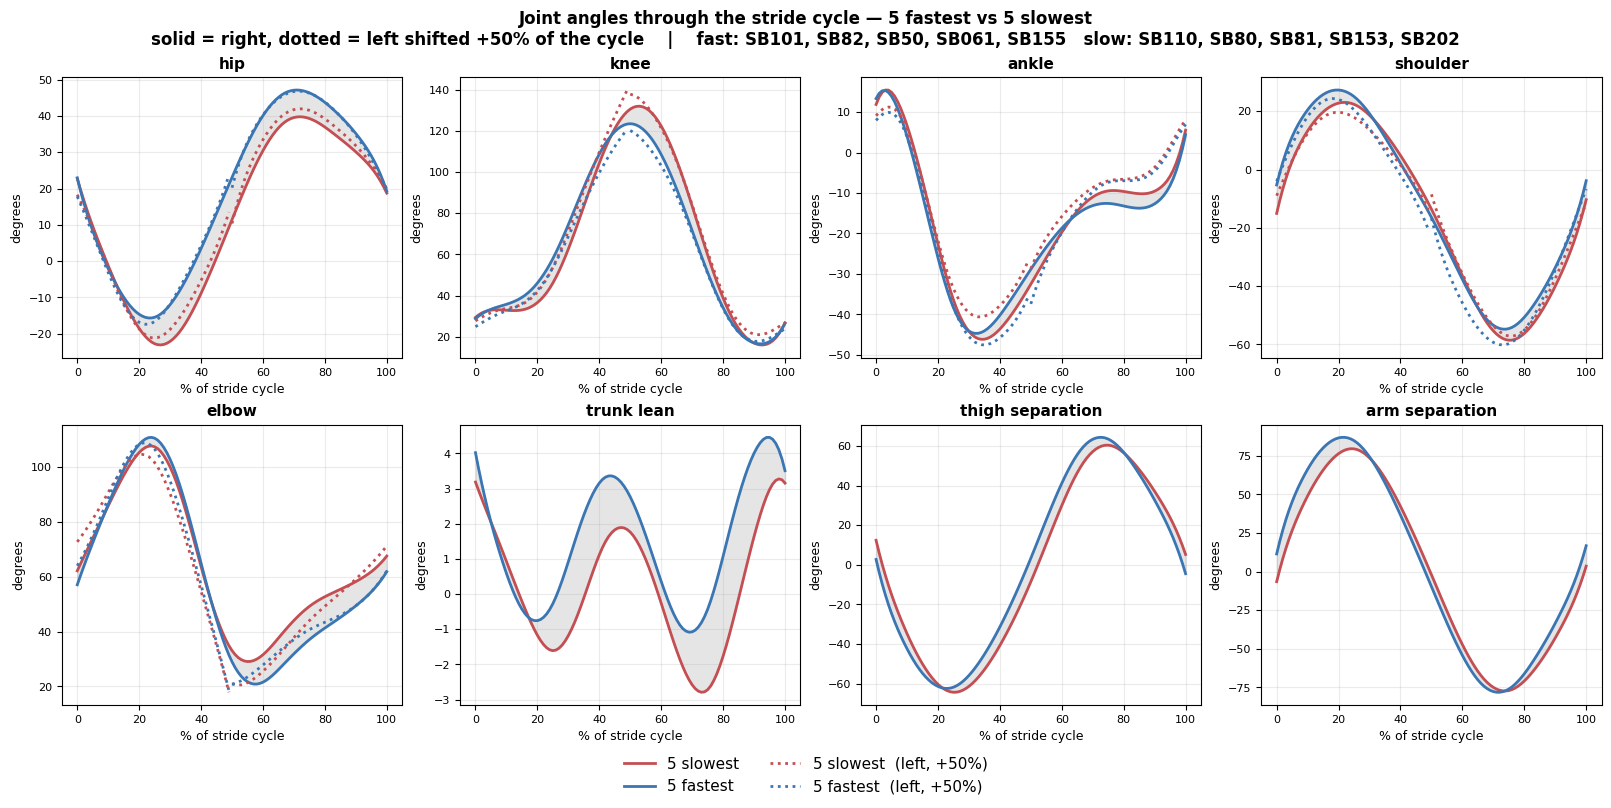

In [10]:
print("saved", OUT.plot_fast_vs_slow(smooth_top, peak_vel, n=5).name)

Right side solid, left dotted and shifted half a cycle. The left leg does the same
thing 50 % later, so shifting lays the two on top of each other and any remaining
gap is a genuine asymmetry. (Flipping the curve vertically only *looks* right
because these curves are near-sinusoidal — it gives r = 0.42 at the ankle where
the shift gives 1.00.)

## I · What the components look like

Two figures, doing two different jobs. The bar chart says **which joints** a
component uses; the skeletons say **what it does** to a body.

The skeletons are the real 64-marker anatomy, the same construction as the MP4s.
The component lives in angle space, so each marker coordinate is regressed on the
participants' PC scores and the fit read off at ±2 SD — a projection of the angle
component, not a second analysis.

Blue is always the faster end, red the slower, worked out from the sign of that
component's correlation with velocity.

saved pc1_loading_ranking.png


saved pc1_anatomy.png


saved pc1_anatomy_acceleration.png


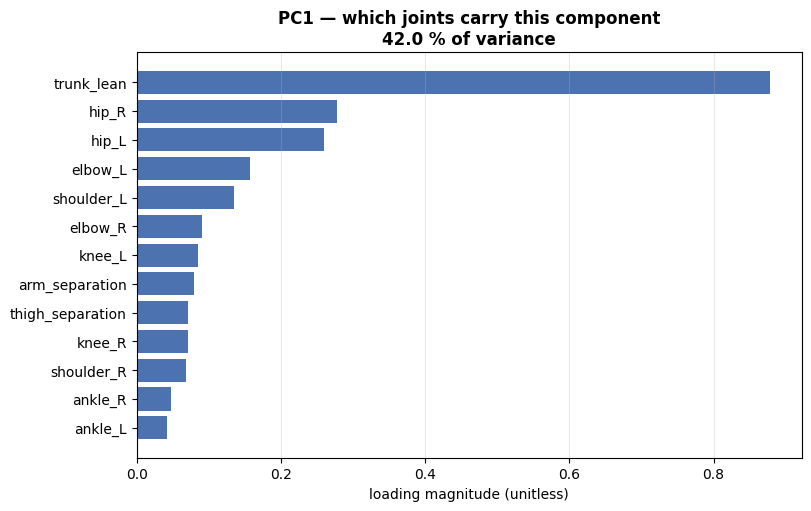

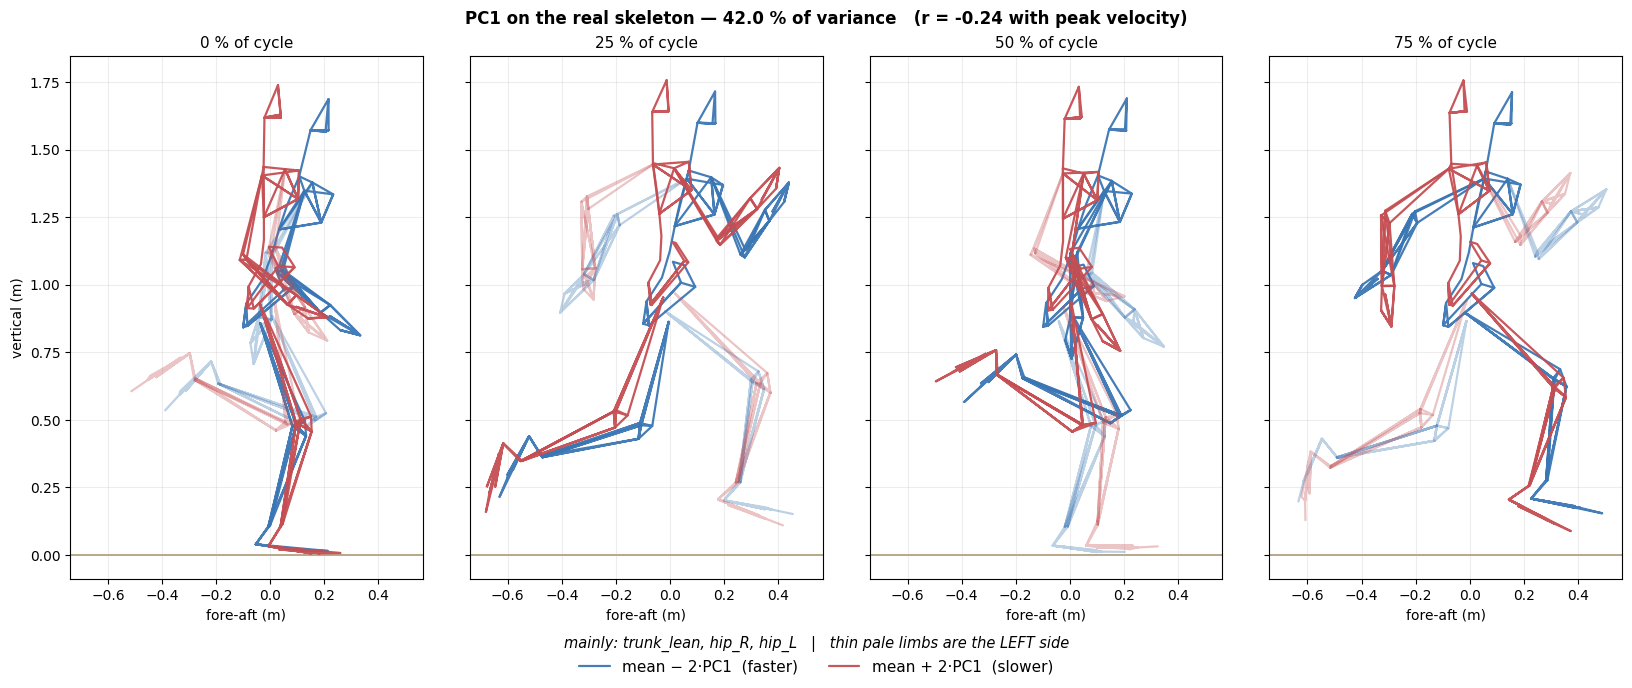

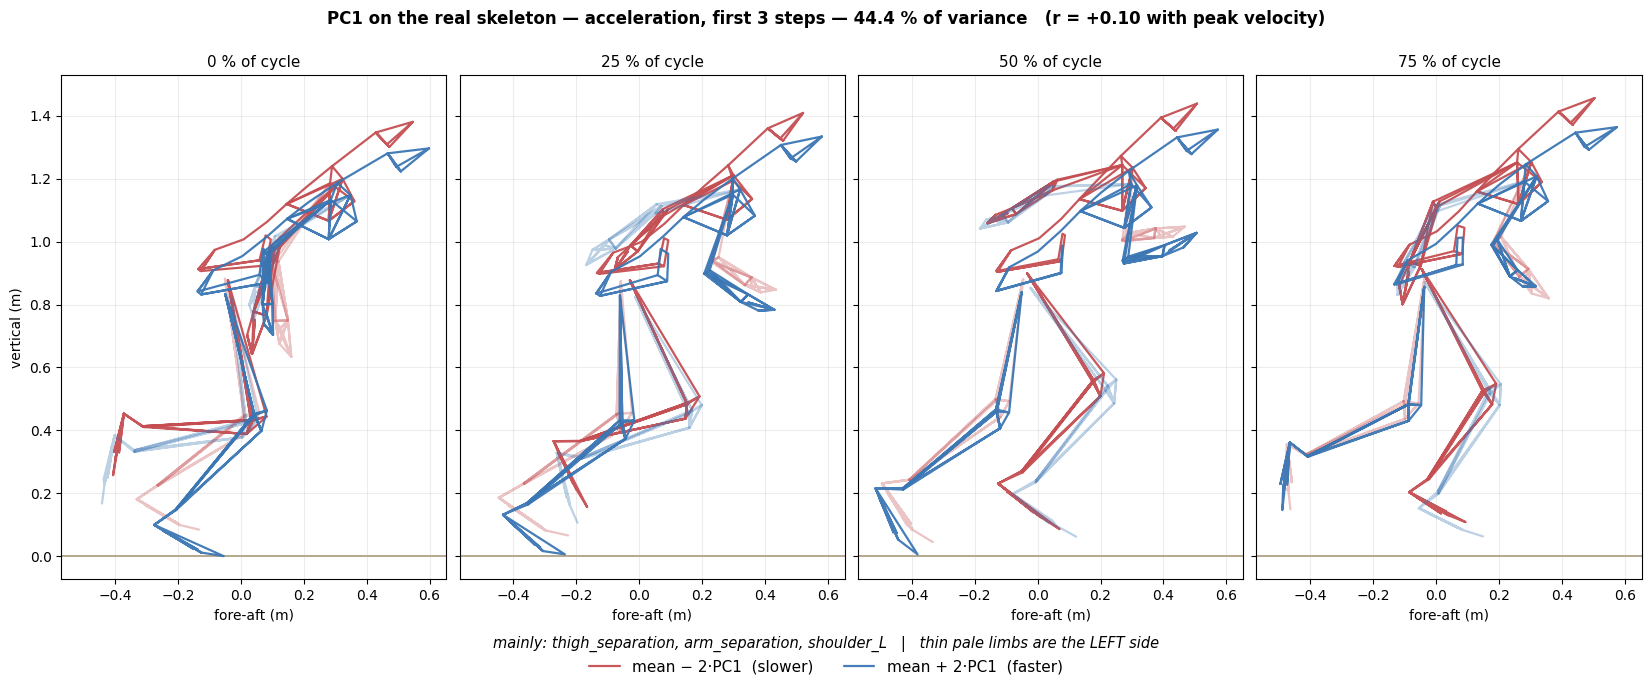

In [11]:
print("saved", OUT.plot_pc_loading_ranking(fpca_top, pc=1).name)
print("saved", OUT.plot_pc_anatomy(cohort_raw, fpca_top, peak_vel, pc=1, k=2.0).name)
print("saved", OUT.plot_pc_anatomy(accel_raw, fpca_acc, peak_vel, pc=1, k=2.0,
                                   title_extra=" — acceleration, first 3 steps",
                                   fname="pc1_anatomy_acceleration.png").name)

## J · The phase itself

Before trusting the acceleration numbers, look at what is being analysed: set in
the blocks, the front foot leaving, then the first three contacts. Left limbs are
faint throughout — in a sagittal view the two sides sit on top of each other and
cross constantly.

saved block_exit_SB25.png


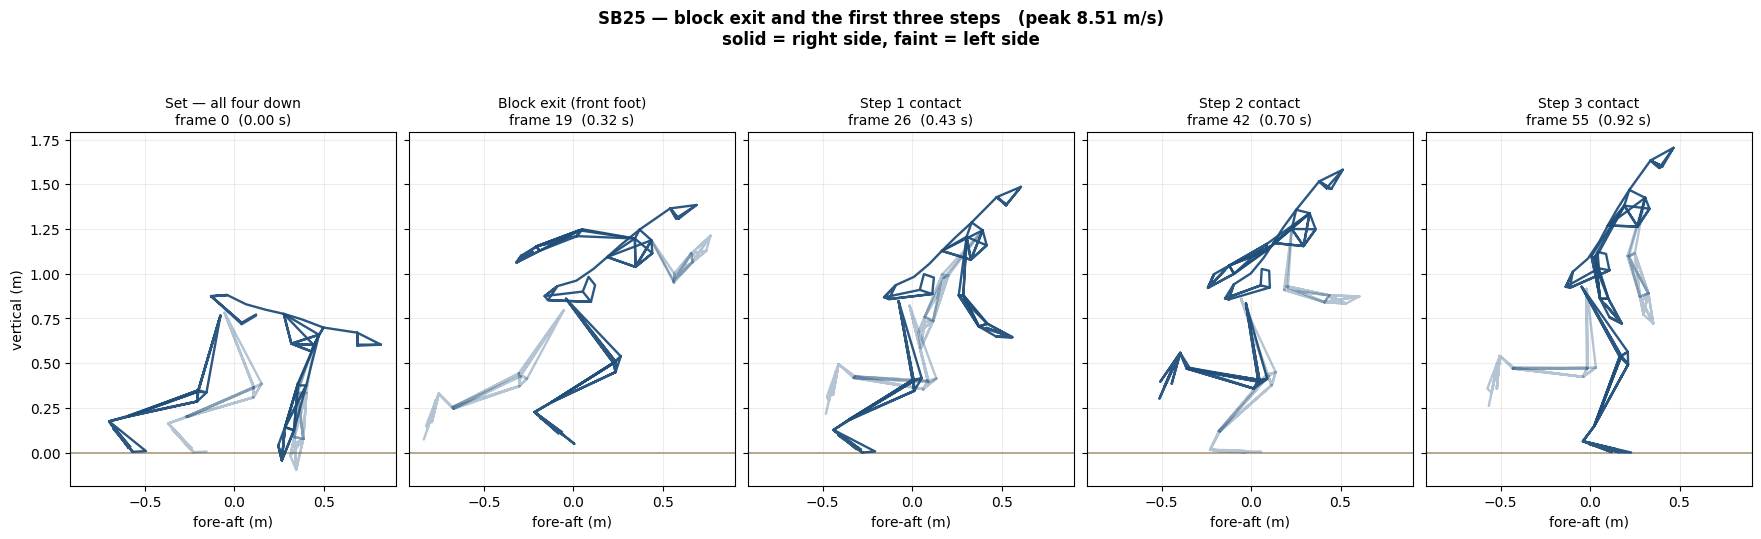

In [12]:
print("saved", OUT.plot_block_exit_steps("SB25").name)

## What this found

### The size artefact is resolved

| | positions (old) | joint angles (new) |
|---|---|---|
| PC1 share of variance | 96.5 % | **42 %** |
| PC1 correlation with body height | +0.535 | **+0.09** |

PC1 no longer measures how big the athlete is. That was the goal, and it is met.

### Which joints predict speed

Plain correlations — stronger and easier to defend than any single component,
because a component mixes thirteen angles together.

| angle | summary | top speed | acceleration |
|---|---|---|---|
| knee | range of motion | **−0.58** | **−0.53** |
| hip | mean angle | **+0.36** | **+0.33** |
| trunk lean | mean angle | not in top 5 | **+0.38** |

**Forward trunk lean predicts speed during acceleration and not at top speed** —
what the literature says should happen, falling out of the data rather than being
asserted. It also explains why PC1 at top speed is trunk-dominated yet barely
correlates with speed: at top speed everyone is near upright, so what is left is
individual posture.

Less knee travel with more hip drive is the other consistent picture, and it holds
in both phases.

### Reading the components

- **Top speed** — PC1 ≈ 42 % (r ≈ −0.24), PC2 ≈ 15 % (r ≈ −0.22).
- **Acceleration** — PC1 ≈ 44 %, PC2 ≈ 17 % (**r ≈ −0.39**, the strongest
  component in either phase).
- **Distrust small components.** One top-speed component once showed the largest
  raw correlation, but its sign flipped when the smoothing penalty changed.
  Anything under about 5 % of variance deserves the same suspicion.

### Fixes that had to happen first

- **The sprint was starting too late** — 0.22–0.25 s after the hands left the
  blocks, so block exit and part of step 1 were discarded before the analysis saw
  them. The start now comes from the set position, detected on 30 of 30 trials.
- **Stride segmentation was broken for 26 of 30**, speed-dependently. After the
  fix, phase spread fell from 57 % to a median of ~4 %, no windows are rejected,
  and SB25's averaged knee range recovered from 68° to 119°.
- **Angles are measured segment-to-segment**, which cannot wrap.
- **Alignment is fitted after the 62 m trim**, giving a 0.000° residual.
- `n = 30`, so these are moderate effects at best. Treat them as worth carrying
  into a larger sample, not as settled.

### Out of scope, deliberately

Kernel PCA, sparse PCA, clustering and regression are all out of scope here. One
method, done clearly, was the goal.